# Corrected line-ratio density histograms and high intrinsic Halpha-dispersion BPT

Compare **SF (blue)**, **NSF (orange)**, **TNSF (red)** and **intrinsic Halpha dispersion >45 km/s (purple)**, in pre-peak, close-to-peak and post-peak order. Plot O3 = [O III]/Hbeta, N2 = [N II]/Halpha and S2 = ([S II]6716+[S II]6730)/Halpha from all-region `_FLUX_CORR` maps. Then plot the actual paired NII and SII BPT coordinates of the high-dispersion sample, with reference classification curves.

Inherited usable-disc selection: inclination <80 degrees; unmasked, finite mass/gas-bin/geometry footprint; mass/gas WCS agreement; finite stellar `SNR_POSTFIT >25`; Halpha and Hbeta detected according to the product's `CUT_SN` and `NOISE`. No new forbidden-line S/N, radius or surface-density cut is added.

- SF: finite `LOGSFR_SURFACE_DENSITY_HII`, proxy EW(Halpha)>6 Angstrom and finite **intrinsic** Halpha dispersion <45 km/s within that footprint.
- NSF: Balmer-detected usable-disc complement of SF.
- TNSF: `NSF & (NII_BPT == 3) & np.isin(SII_BPT, [2, 3])`.
- High dispersion: Balmer-detected usable-disc pixels with finite **intrinsic** Halpha dispersion strictly >45 km/s, regardless of EW or BPT class. Intrinsic dispersion is `sqrt(HA6562_SIGMA**2 - HA6562_SIGMA_CORR**2)` only where the squared difference is positive and finite; unresolved values remain unavailable. Exactly 45 is excluded from this sample.

These four samples overlap: TNSF and high dispersion are subsets of NSF and can overlap each other. They are not a four-way partition. Each nonempty histogram is independently normalized as `count / (N_finite * bin_width)` and integrates to one. This compares distribution shapes; areas do not encode NSF fractions. Identical full-range bins are used across all categories and stages for each ratio. X is log10 ratio; Y is density per dex. Counts, ranges and medians are printed before plotting.

BPT coordinates require both axes finite and come from the same pixels, separately for each diagram. All paired points are drawn without subsampling or tail clipping. Transparency indicates overplotting, not calibrated density. Pooled spaxels weight larger footprints more; shared gas bins are not independent spectra. TNSF/high dispersion are operational selections, not unique physical-source identifications. Missing products and unavailable ratios are reported in QC/count tables. No FITS products or source notebooks are modified; figures use `plt.show()` without saving files.


In [1]:
from pathlib import Path
import hashlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy import units as u
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "v3tk_v7.6.8").is_dir():
    PROJECT_ROOT = Path("/Users/Igniz/Desktop/ICRAR/further")
DATA_ROOT = PROJECT_ROOT / "v3tk_v7.6.8"
CATALOG_PATH = PROJECT_ROOT / "mauve_master_wiki_newclass.fits"
GEOMETRY_PATH = PROJECT_ROOT / "MAUVE_effective_radii.csv"
MASS_FILE_PATTERN = "{galid}_spatial_binning_maps_further.fits"
SFR_FILE_PATTERNS = ("{galid}_gas_bin_maps_further.fits", "{galid}_gas_BIN_maps_further.fits")
EW_FILE_PATTERNS = ("{galid}_proxy_EW_maps_further.fits", "{galid}_proxy_EW_maps.fits")
MASK_FILE_PATTERN = "{galid}_mask.fits"
SFH_FILE_PATTERN = "{galid}_sfh_maps.fits"
MASS_HDU, BIN_HDU_MASS, BIN_HDU_GAS = "LOGMASS_SURFACE_DENSITY", "BINID", "BIN_ID"
SFR_HDU, EW_HDU = "LOGSFR_SURFACE_DENSITY_HII", "PROXY_EWHA"
HALPHA_SIGMA_OBS_HDU, HALPHA_SIGMA_CORR_HDU = "HA6562_SIGMA", "HA6562_SIGMA_CORR"
MASK_TABLE_HDU, MASK_COLUMN = "MASKFILE", "MASK"
SFH_SNR_POSTFIT_HDU = "SNR_POSTFIT"
EW_HA_MIN, HALPHA_SIGMA_MAX, SFH_SNR_POSTFIT_MIN = 6.0, 45.0, 25.0
I_MAX_PRIMARY, WCS_TOLERANCE_ARCSEC = 80.0, 0.05
BALMER_LINES = ("HB4861", "HA6562")
REASON_LABELS = ("BPT: stable non-HII", "BPT: weak/ambiguous/unavailable", "HII SFR unavailable",
                 "EW unavailable", "EW <= 6", "Dispersion unavailable", "Dispersion >= 45")
CATEGORY_ORDER = ("SF", "NSF", "TNSF", "SIGMA_GT45")
OBSERVABLE_ORDER = ("O3", "N2", "S2")
N_HIST_BINS = 60
CATEGORY_COLORS = dict(zip(CATEGORY_ORDER, ("#2166ac", "#e08214", "#b2182b", "#756bb1")))
CATEGORY_STYLES = dict(zip(CATEGORY_ORDER, ("-", "-", "-", "-")))
OBSERVABLE_LABELS = {
    "Halpha": r"$\log_{10}\Sigma_{\mathrm{H}\alpha,\mathrm{corr}}$ [erg s$^{-1}$ kpc$^{-2}$]",
    "OIII5006_SB": r"$\log_{10}\Sigma_{[\mathrm{O\,III}]5006,\mathrm{corr}}$ [erg s$^{-1}$ kpc$^{-2}$]",
    "NII6583_SB": r"$\log_{10}\Sigma_{[\mathrm{N\,II}]6583,\mathrm{corr}}$ [erg s$^{-1}$ kpc$^{-2}$]",
    "SII_SUM_SB": r"$\log_{10}\Sigma_{[\mathrm{S\,II}]6716+6730,\mathrm{corr}}$ [erg s$^{-1}$ kpc$^{-2}$]",
    "O3": r"$\log_{10}([\mathrm{O\,III}]5007/\mathrm{H}\beta)_{\mathrm{corr}}$",
    "N2": r"$\log_{10}([\mathrm{N\,II}]6583/\mathrm{H}\alpha)_{\mathrm{corr}}$",
    "S2": r"$\log_{10}(([\mathrm{S\,II}]6716+6731)/\mathrm{H}\alpha)_{\mathrm{corr}}$",
}
OBSERVABLE_TITLES = {"Halpha": "Halpha surface brightness", "OIII5006_SB": "OIII5006 surface brightness",
    "NII6583_SB": "NII6583 surface brightness", "SII_SUM_SB": "SII6716+SII6730 surface brightness",
    "O3": "O3 ratio", "N2": "N2 ratio", "S2": "S2 ratio"}
mpl.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.grid": False})

SOURCE_NOTEBOOK_SHA256 = "39e288df0c7d86b4b7a9803b41de63cb797ea999e639b64758c75c3abae849e6"
CATEGORY_LABELS = {c: c for c in CATEGORY_ORDER}
CATEGORY_LABELS["SIGMA_GT45"] = r"Intrinsic $\sigma(\mathrm{H}\alpha)>45$ km/s"
print("Source SHA256:", SOURCE_NOTEBOOK_SHA256)


Source SHA256: 39e288df0c7d86b4b7a9803b41de63cb797ea999e639b64758c75c3abae849e6


## Inherited product discovery and selection helpers
Self-contained copies of the source helpers; no execution of an external notebook is needed.

In [2]:
def normalise_stage_label(value) -> str:
    mapping = {
        1: "pre-peak", 1.0: "pre-peak", "1": "pre-peak",
        2: "close-to-peak", 2.0: "close-to-peak", "2": "close-to-peak",
        3: "post-peak", 3.0: "post-peak", "3": "post-peak",
        "prepeak": "pre-peak", "pre-peak": "pre-peak",
        "close-to-peak": "close-to-peak", "closetopeak": "close-to-peak",
        "near-peak": "close-to-peak", "postpeak": "post-peak", "post-peak": "post-peak",
    }
    key = value if isinstance(value, (int, float)) else str(value).strip().lower().replace(" ", "")
    if key not in mapping:
        raise ValueError(f"Unrecognised RPS/infall stage label: {value!r}")
    return mapping[key]

def first_existing(paths):
    for path in paths:
        for candidate in (path, Path(str(path) + ".gz")):
            if candidate.exists():
                return candidate
    return None

def load_fits_map(path: Path, hdu_name: str, *, return_header: bool = False):
    with fits.open(path, memmap=True) as hdul:
        names = {hdu.name.upper() for hdu in hdul}
        if hdu_name.upper() not in names:
            raise KeyError(f"{path}: missing HDU {hdu_name}; available={sorted(names)}")
        hdu = hdul[hdu_name]
        data = np.asarray(hdu.data, dtype=float).copy()
        header = hdu.header.copy()
    return (data, header) if return_header else data

def load_ngist_mask(path: Path, shape):
    with fits.open(path, memmap=True) as hdul:
        if MASK_TABLE_HDU not in hdul:
            raise KeyError(f"{path}: missing table HDU {MASK_TABLE_HDU}")
        table = hdul[MASK_TABLE_HDU].data
        if MASK_COLUMN not in table.names:
            raise KeyError(f"{path}: missing mask column {MASK_COLUMN}; available={table.names}")
        flat = np.asarray(table[MASK_COLUMN], dtype=int)
    if flat.size != int(np.prod(shape)):
        raise ValueError(f"{path}: mask length {flat.size} cannot reshape to {shape}")
    return flat.reshape(shape)

def celestial_wcs_separation_arcsec(header_a, header_b, shape):
    wa, wb = WCS(header_a).celestial, WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        return np.inf
    ny, nx = shape
    x = np.array([0, nx - 1, 0, nx - 1, (nx - 1) / 2])
    y = np.array([0, 0, ny - 1, ny - 1, (ny - 1) / 2])
    raa, deca = wa.pixel_to_world_values(x, y)
    rab, decb = wb.pixel_to_world_values(x, y)
    cosd = np.cos(np.deg2rad((deca + decb) / 2))
    return float(np.nanmax(np.hypot((raa - rab) * cosd, deca - decb)) * 3600.0)

def tangent_offsets_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(float(ra0_deg)), np.deg2rad(float(dec0_deg))
    dra = (ra - ra0 + np.pi) % (2 * np.pi) - np.pi
    cosc = np.sin(dec0) * np.sin(dec) + np.cos(dec0) * np.cos(dec) * np.cos(dra)
    with np.errstate(divide="ignore", invalid="ignore"):
        east = np.cos(dec) * np.sin(dra) / cosc
        north = (np.cos(dec0) * np.sin(dec) - np.sin(dec0) * np.cos(dec) * np.cos(dra)) / cosc
    return east * 206264.806247, north * 206264.806247

def calculate_deprojected_radius(shape, header, component_rows: pd.DataFrame):
    # Minimum elliptical R/Re over the physical components of one product.
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("No celestial WCS available for radius calculation")
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = wcs.pixel_to_world_values(xx, yy)
    radius = np.full(shape, np.inf, dtype=float)
    for _, component in component_rows.iterrows():
        east, north = tangent_offsets_arcsec(
            ra, dec, component.center_ra_deg, component.center_dec_deg
        )
        pa = np.deg2rad(float(component.pa_deg_east_of_north))
        major = east * np.sin(pa) + north * np.cos(pa)
        minor = east * np.cos(pa) - north * np.sin(pa)
        component_radius = np.sqrt(
            (major / float(component.a_re_arcsec)) ** 2
            + (minor / float(component.b_re_arcsec)) ** 2
        )
        radius = np.minimum(radius, component_radius)
    radius[~np.isfinite(radius)] = np.nan
    return radius

def intrinsic_sigma_from_maps(sigma_obs, sigma_corr):
    sigma2 = np.asarray(sigma_obs, dtype=float) ** 2 - np.asarray(sigma_corr, dtype=float) ** 2
    result = np.full(sigma2.shape, np.nan, dtype=float)
    valid = np.isfinite(sigma2) & (sigma2 > 0)
    result[valid] = np.sqrt(sigma2[valid])
    return result

def load_galaxy_maps(row, geometry):
    mass, mass_header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    mass_bin = load_fits_map(row.mass_path, BIN_HDU_MASS)
    gas_bin, gas_header = load_fits_map(row.sfr_path, BIN_HDU_GAS, return_header=True)
    sfr = load_fits_map(row.sfr_path, SFR_HDU)
    ew_ha = load_fits_map(row.ew_path, EW_HDU)
    sigma_obs = load_fits_map(row.sfr_path, HALPHA_SIGMA_OBS_HDU)
    sigma_corr = load_fits_map(row.sfr_path, HALPHA_SIGMA_CORR_HDU)
    snr_postfit = load_fits_map(row.sfh_path, SFH_SNR_POSTFIT_HDU)
    shapes = {a.shape for a in (
        mass, mass_bin, gas_bin, sfr, ew_ha, sigma_obs, sigma_corr, snr_postfit
    )}
    if len(shapes) != 1:
        raise ValueError(f"{row.GALID}: map shape mismatch {sorted(shapes)}")
    wcs_sep = celestial_wcs_separation_arcsec(mass_header, gas_header, mass.shape)
    if not np.isfinite(wcs_sep) or wcs_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: mass/gas WCS mismatch {wcs_sep:.4f} arcsec")
    ngist_mask = load_ngist_mask(row.mask_path, mass.shape)
    components = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    radius_re = calculate_deprojected_radius(mass.shape, mass_header, components)
    sigma_intrinsic = intrinsic_sigma_from_maps(sigma_obs, sigma_corr)
    valid = (
        np.isfinite(mass) & np.isfinite(gas_bin) & (ngist_mask == 0) & np.isfinite(radius_re)
    )
    sf = (
        valid & np.isfinite(sfr) & np.isfinite(ew_ha) & (ew_ha > EW_HA_MIN)
        & np.isfinite(sigma_intrinsic) & (sigma_intrinsic < HALPHA_SIGMA_MAX)
    )
    maps = {
        "log_sigma_star": mass,
        "log_sigma_sfr": sfr,
        "radius_re": radius_re,
        "snr_postfit": snr_postfit,
        "sigma_intrinsic": sigma_intrinsic,
        "gas_bin_id": gas_bin,
        "ew_ha": ew_ha,
        "valid_disc_mask": valid,
        "sf_mask": sf,
        "mass_header": mass_header,
        "wcs_separation_arcsec": wcs_sep,
    }
    return add_detection_categories(maps, row, ew_ha, sigma_intrinsic)

def add_detection_categories(maps, row, ew_ha, sigma_intrinsic):
    """Use Balmer-only ND and preserve the original SF selection exactly."""
    valid, sf = maps["valid_disc_mask"], maps["sf_mask"]
    detected = {}
    invalid_any = np.zeros(valid.shape, dtype=bool)
    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header
        sn_cut, flux_floor = float(header["CUT_SN"]), float(header["NOISE"])
        if not (np.isfinite(sn_cut) and sn_cut > 0 and np.isfinite(flux_floor) and flux_floor > 0):
            raise ValueError(f"{row.GALID}: invalid detection thresholds")
        if str(header["BPTMODE"]).strip().lower() != "both":
            raise ValueError(f"{row.GALID}: expected the original both-BPT selection")
        for line in BALMER_LINES:
            flux = np.asarray(hdul[line + "_FLUX"].data, dtype=float)
            error = np.asarray(hdul[line + "_FLUX_ERR"].data, dtype=float)
            if flux.shape != valid.shape or error.shape != valid.shape:
                raise ValueError(f"{row.GALID}: {line} shape mismatch")
            measurable = np.isfinite(flux) & np.isfinite(error) & (error > 0)
            invalid_any |= ~measurable
            with np.errstate(divide="ignore", invalid="ignore"):
                detected[line] = measurable & (flux / error >= sn_cut) & (flux >= flux_floor)
        # Do not use the old NII_HA_BPT / SII_HA_BPT ratio HDUs as class maps.
        nii = np.asarray(hdul["NII_BPT"].data).copy()
        sii = np.asarray(hdul["SII_BPT"].data).copy()
        for name, arr in (("NII_BPT", nii), ("SII_BPT", sii)):
            if arr.shape != valid.shape or not np.isin(arr[valid], [-1, 0, 1, 2, 3]).all():
                raise ValueError(f"{row.GALID}: invalid {name} class map")
        provenance = {key: header.get(key, "not recorded")
                      for key in ("CUT_SN", "NOISE", "BPTMODE", "BPTLIMIT", "DUSTLAW")}
    balmer_detected = detected["HA6562"] & detected["HB4861"]
    if np.any(sf & ~balmer_detected):
        raise AssertionError(f"{row.GALID}: original SF includes a Balmer non-detection")
    nd = valid & ~balmer_detected
    nsf = valid & balmer_detected & ~sf
    # Exclusive bookkeeping, in this order: HII gate -> EW gate -> sigma gate.
    # This is a first-failed-gate decomposition, not a unique physical cause.
    has_sfr = np.isfinite(maps["log_sigma_sfr"])
    stable_non_hii = np.isin(nii, [2, 3]) | np.isin(sii, [2, 3])
    both_hii = (nii == 1) & (sii == 1)
    conditions = (
        ~has_sfr & stable_non_hii,
        ~has_sfr & ~both_hii,
        ~has_sfr,
        ~np.isfinite(ew_ha),
        ew_ha <= EW_HA_MIN,
        ~np.isfinite(sigma_intrinsic),
        sigma_intrinsic >= HALPHA_SIGMA_MAX,
    )
    remainder = nsf.copy()
    reasons = {}
    for label, condition in zip(REASON_LABELS, conditions):
        reasons[label] = remainder & condition
        remainder &= ~condition
    if remainder.any():
        raise AssertionError(f"{row.GALID}: unexplained detected non-SF pixels")
    category_sum = sf.astype(np.int8) + nd + nsf
    assert np.array_equal(category_sum, valid.astype(np.int8))
    assert np.array_equal(np.sum(list(reasons.values()), axis=0), nsf.astype(int))
    tnsf = nsf & (nii == 3) & np.isin(sii, [2, 3])
    assert not np.any(tnsf & ~nsf)
    assert np.all(nii[tnsf] == 3)
    assert np.isin(sii[tnsf], [2, 3]).all()
    maps.update({
        "tnsf_mask": tnsf, "nii_bpt_class": nii, "sii_bpt_class": sii,
        "nd_mask": nd, "nsf_mask": nsf, "balmer_detected_mask": balmer_detected,
        "line_detected": detected, "nsf_reasons": reasons,
        "nd_invalid_mask": nd & invalid_any,
        "nd_measured_below_cut_mask": nd & ~invalid_any,
        "detection_provenance": provenance,
    })
    return maps

In [3]:
def read_master_catalogue(path):
    with fits.open(path) as hdul:
        table = hdul[1].data
        frame = pd.DataFrame({
            "galaxy": [str(value).strip() for value in table["Galaxy"]],
            "logMstar": np.asarray(table["logMstar"], dtype=float),
            "stage_code": np.asarray(table["class"], dtype=float),
        })
    frame["stage"] = frame.stage_code.map(normalise_stage_label)
    return frame


def discover_products(data_root):
    rows = []
    for folder in sorted(path for path in data_root.iterdir()
                         if path.is_dir() and not path.name.endswith("_logs")):
        galid = folder.name
        rows.append({
            "GALID": galid,
            "mass_path": first_existing([folder / MASS_FILE_PATTERN.format(galid=galid)]),
            "sfr_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in SFR_FILE_PATTERNS
            ]),
            "ew_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in EW_FILE_PATTERNS
            ]),
            "mask_path": first_existing([folder / MASK_FILE_PATTERN.format(galid=galid)]),
            "sfh_path": first_existing([
                folder / SFH_FILE_PATTERN.format(galid=galid)
            ]),
        })
    return pd.DataFrame(rows)


STAGE_ORDER = ("pre-peak", "close-to-peak", "post-peak")
PANEL_ORDER = STAGE_ORDER + ("all stages",)
STAGE_LABELS = {
    "pre-peak": "Pre-peak",
    "close-to-peak": "Close-to-peak",
    "post-peak": "Post-peak",
    "all stages": "All stages",
}

master = read_master_catalogue(CATALOG_PATH)
geometry = pd.read_csv(GEOMETRY_PATH)
required_geometry = {
    "galaxy", "notebook_product_id", "mauve_infall_stage", "center_ra_deg",
    "center_dec_deg", "inclination_deg", "pa_deg_east_of_north",
    "a_re_arcsec", "b_re_arcsec",
}
missing_geometry = required_geometry - set(geometry.columns)
if missing_geometry:
    raise KeyError(f"{GEOMETRY_PATH}: missing columns {sorted(missing_geometry)}")

geometry = geometry.merge(
    master[["galaxy", "logMstar", "stage"]], on="galaxy", how="left",
    validate="one_to_one",
)
geometry["stage_from_geometry"] = geometry.mauve_infall_stage.map(normalise_stage_label)
if not geometry.stage.eq(geometry.stage_from_geometry).all():
    raise RuntimeError("Stage disagreement between the master and effective-radius catalogues")

product_meta = []
for galid, group in geometry.groupby("notebook_product_id", sort=False):
    if group.stage.nunique() != 1:
        raise RuntimeError(f"{galid}: physical components have inconsistent stages")
    product_meta.append({
        "GALID": galid,
        "components": ",".join(group.galaxy),
        "stage": group.stage.iloc[0],
        "inclination": float(group.inclination_deg.max()),
    })

inventory = pd.DataFrame(product_meta).merge(
    discover_products(DATA_ROOT), on="GALID", how="left", validate="one_to_one"
)
candidates = inventory.loc[
    inventory.stage.isin(STAGE_ORDER) & inventory.inclination.lt(I_MAX_PRIMARY)
].sort_values(["stage", "GALID"]).reset_index(drop=True)



## Load corrected ratios, retain paired BPT coordinates, and report QC

In [4]:
def positive_log10(values):
    result = np.full(values.shape, np.nan)
    good = np.isfinite(values) & (values > 0)
    result[good] = np.log10(values[good])
    return result

def corrected_ratios(row, shape):
    lines = ("HA6562", "HB4861", "OIII5006", "NII6583", "SII6716", "SII6730")
    flux = {}
    with fits.open(row.sfr_path, memmap=True) as hdul:
        for line in lines:
            hdu = hdul[line + "_FLUX_CORR"]
            if hdu.data.shape != shape or hdu.header.get("BUNIT", "").strip() != "1e-20 erg s-1 cm-2":
                raise ValueError(f"{row.GALID}: corrected {line} shape/unit mismatch")
            flux[line] = np.asarray(hdu.data, dtype=float).copy()
    ratios = {}
    for key, numerator_lines, denominator in (
        ("O3", ("OIII5006",), "HB4861"),
        ("N2", ("NII6583",), "HA6562"),
        ("S2", ("SII6716", "SII6730"), "HA6562"),
    ):
        good = np.isfinite(flux[denominator]) & (flux[denominator] > 0)
        numerator = np.zeros(shape)
        for line in numerator_lines:
            good &= np.isfinite(flux[line]) & (flux[line] > 0)
            numerator += flux[line]
        values = np.full(shape, np.nan)
        with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
            values[good] = numerator[good] / flux[denominator][good]
        ratios[key] = positive_log10(values)
    return ratios

VALUES_BY_GALAXY, BPT_BY_GALAXY = [], []
qc_rows, count_rows, bpt_rows, overlap_rows, provenance_rows = [], [], [], [], []
for row in candidates.itertuples(index=False):
    flags = []
    for label in ("mass", "sfr", "ew", "mask", "sfh"):
        path = getattr(row, label + "_path")
        if not isinstance(path, Path) or not path.exists():
            flags.append("missing_" + label + "_product")
    if not flags:
        try:
            maps = load_galaxy_maps(row, geometry)
            keep = maps['valid_disc_mask'] & np.isfinite(maps['snr_postfit']) & (maps['snr_postfit'] > SFH_SNR_POSTFIT_MIN)
            sf, nsf, tnsf = (maps[k] & keep for k in ('sf_mask', 'nsf_mask', 'tnsf_mask'))
            sigma = maps['sigma_intrinsic']
            high = keep & maps['balmer_detected_mask'] & np.isfinite(sigma) & (sigma > HALPHA_SIGMA_MAX)
            assert not np.any(high & ~nsf)
            assert not np.any(high & sf)
            assert not np.any(tnsf & ~nsf)
            assert np.all(sigma[high] > 45)
            selections = dict(zip(CATEGORY_ORDER, (sf, nsf, tnsf, high)))
            ratios = corrected_ratios(row, keep.shape)
            local_values, local_counts, local_bpt_counts = [], [], []
            record = {'GALID': row.GALID, 'stage': row.stage, 'N_selected': int(high.sum())}
            for category, mask in selections.items():
                for observable in OBSERVABLE_ORDER:
                    values = ratios[observable]
                    finite = mask & np.isfinite(values)
                    local_values.append(dict(GALID=row.GALID, stage=row.stage, category=category,
                                             observable=observable, values=values[finite]))
                    local_counts.append(dict(GALID=row.GALID, stage=row.stage, category=category,
                        observable=observable, N_selected=int(mask.sum()), N_finite=int(finite.sum()),
                        N_unavailable=int(mask.sum()-finite.sum()),
                        N_gas_bins=int(np.unique(maps['gas_bin_id'][finite]).size)))
            for diagram, ratio in (('NII', 'N2'), ('SII', 'S2')):
                paired = high & np.isfinite(ratios[ratio]) & np.isfinite(ratios['O3'])
                indices = np.flatnonzero(paired)
                record[diagram] = np.column_stack((ratios[ratio][paired], ratios['O3'][paired]))
                assert np.array_equal(record[diagram][:, 0], ratios[ratio].ravel()[indices])
                assert np.array_equal(record[diagram][:, 1], ratios['O3'].ravel()[indices])
                local_bpt_counts.append(dict(GALID=row.GALID, stage=row.stage, diagram=diagram,
                    N_selected=int(high.sum()), N_paired=int(paired.sum()),
                    N_unavailable=int(high.sum()-paired.sum())))
            VALUES_BY_GALAXY.extend(local_values)
            count_rows.extend(local_counts)
            BPT_BY_GALAXY.append(record)
            bpt_rows.extend(local_bpt_counts)
            overlap_rows.append(dict(GALID=row.GALID, stage=row.stage, N_SF=int(sf.sum()),
                N_NSF=int(nsf.sum()), N_TNSF=int(tnsf.sum()), N_high_sigma=int(high.sum()),
                N_TNSF_and_high_sigma=int((tnsf & high).sum())))
            provenance_rows.append(dict(GALID=row.GALID, **maps['detection_provenance']))
        except Exception as exc:
            flags.append(f'load_error:{type(exc).__name__}:{exc}')
    qc_rows.append(dict(GALID=row.GALID, stage=row.stage, QC_flag=';'.join(flags) if flags else 'OK'))

SAMPLE_QC = pd.DataFrame(qc_rows)
MEASUREMENT_COUNTS = pd.DataFrame(count_rows)
BPT_COUNTS = pd.DataFrame(bpt_rows)
OVERLAP_COUNTS = pd.DataFrame(overlap_rows)
display(SAMPLE_QC)
display(pd.DataFrame(provenance_rows))
for stage in STAGE_ORDER:
    ids = SAMPLE_QC.loc[SAMPLE_QC.stage.eq(stage) & SAMPLE_QC.QC_flag.eq('OK'), 'GALID'].tolist()
    print(f'{STAGE_LABELS[stage]}: {len(ids)} passing products: {", ".join(ids)}')
    if not ids:
        raise RuntimeError(f'No {stage} products pass QC')
display(MEASUREMENT_COUNTS.groupby(['stage', 'category', 'observable'])[['N_selected', 'N_finite', 'N_unavailable', 'N_gas_bins']].sum())
display(OVERLAP_COUNTS)
display(BPT_COUNTS)


,GALID,stage,QC_flag
0,NGC4298,close-to-peak,OK
1,NGC4424,close-to-peak,OK
2,NGC4501,close-to-peak,OK
3,NGC4654,close-to-peak,OK
4,NGC4694,close-to-peak,OK
5,IC3392,post-peak,OK
6,NGC4064,post-peak,OK
7,NGC4293,post-peak,OK
8,NGC4380,post-peak,OK
9,NGC4394,post-peak,OK


,GALID,CUT_SN,NOISE,BPTMODE,BPTLIMIT,DUSTLAW
0,NGC4298,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti
1,NGC4424,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti
2,NGC4501,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti
3,NGC4654,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti
4,NGC4694,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti
5,IC3392,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti
6,NGC4064,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti
7,NGC4293,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti
8,NGC4380,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti
9,NGC4394,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti


Pre-peak: 8 passing products: NGC4189, NGC4254, NGC4294, NGC4321, NGC4351, NGC4383, NGC4535, NGC4567_8
Close-to-peak: 5 passing products: NGC4298, NGC4424, NGC4501, NGC4654, NGC4694
Post-peak: 13 passing products: IC3392, NGC4064, NGC4293, NGC4380, NGC4394, NGC4405, NGC4419, NGC4450, NGC4457, NGC4569, NGC4580, NGC4606, NGC4698


N_selected  N_finite  N_unavailable  \
stage         category   observable                                        
close-to-peak NSF        N2              488865    488603            262   
                         O3              488865    486897           1968   
                         S2              488865    488345            520   
              SF         N2              720842    720842              0   
                         O3              720842    720842              0   
                         S2              720842    720842              0   
              SIGMA_GT45 N2              125828    125566            262   
                         O3              125828    124776           1052   
                         S2              125828    125308            520   
              TNSF       N2                6217      6217              0   
                         O3                6217      6217              0   
                         S2                6217      6217              0   
post-peak     NSF        N2              815887    815489            398   
                         O3              815887    811269           4618   
                         S2              815887    810743           5144   
              SF         N2              222427    222427              0   
                         O3              222427    222427              0   
                         S2              222427    222427              0   
              SIGMA_GT45 N2              454706    454308            398   
                         O3              454706    452706           2000   
                         S2              454706    449814           4892   
              TNSF       N2               94780     94780              0   
                         O3               94780     94780              0   
                         S2               94780     94780              0   
pre-peak      NSF        N2              929104    929104              0   
                         O3              929104    923230           5874   
                         S2              929104    929091             13   
              SF         N2             1420915   1420915              0   
                         O3             1420915   1420915              0   
                         S2             1420915   1420915              0   
              SIGMA_GT45 N2              247677    247677              0   
                         O3              247677    247426            251   
                         S2              247677    247664             13   
              TNSF       N2                8852      8852              0   
                         O3                8852      8852              0   
                         S2                8852      8852              0   

                                     N_gas_bins  
stage         category   observable              
close-to-peak NSF        N2               55999  
                         O3               55574  
                         S2               55981  
              SF         N2               56923  
                         O3               56923  
                         S2               56923  
              SIGMA_GT45 N2               26586  
                         O3               26259  
                         S2               26568  
              TNSF       N2                2088  
                         O3                2088  
                         S2                2088  
post-peak     NSF        N2              130686  
                         O3              129689  
                         S2              130356  
              SF         N2               23182  
                         O3               23182  
                         S2               23182  
              SIGMA_GT45 N2               90431  
                         O3               89728  
                         S2               90142 

,GALID,stage,N_SF,N_NSF,N_TNSF,N_high_sigma,N_TNSF_and_high_sigma
0,NGC4298,close-to-peak,138402,43104,114,2424,100
1,NGC4424,close-to-peak,8994,37811,79,30589,47
2,NGC4501,close-to-peak,251607,261968,5577,54149,4676
3,NGC4654,close-to-peak,320781,117845,384,14823,158
4,NGC4694,close-to-peak,1058,28137,63,23843,25
5,IC3392,post-peak,13888,9123,45,1650,20
6,NGC4064,post-peak,3273,33921,974,27076,745
7,NGC4293,post-peak,471,63400,4165,50989,3192
8,NGC4380,post-peak,56075,51190,615,570,183
9,NGC4394,post-peak,30430,45294,1197,10419,716


,GALID,stage,diagram,N_selected,N_paired,N_unavailable
0,NGC4298,close-to-peak,NII,2424,2424,0
1,NGC4298,close-to-peak,SII,2424,2424,0
2,NGC4424,close-to-peak,NII,30589,30256,333
3,NGC4424,close-to-peak,SII,30589,30211,378
4,NGC4501,close-to-peak,NII,54149,53451,698
5,NGC4501,close-to-peak,SII,54149,53256,893
6,NGC4654,close-to-peak,NII,14823,14818,5
7,NGC4654,close-to-peak,SII,14823,14818,5
8,NGC4694,close-to-peak,NII,23843,23827,16
9,NGC4694,close-to-peak,SII,23843,23801,42


## Density histograms
Each nonempty curve integrates to one. The same full-range bin edges apply to all stages and samples for a ratio.

In [5]:
POOLED = {}
for stage in STAGE_ORDER:
    for observable in OBSERVABLE_ORDER:
        for category in CATEGORY_ORDER:
            arrays = [r['values'] for r in VALUES_BY_GALAXY if r['stage'] == stage
                      and r['observable'] == observable and r['category'] == category]
            POOLED[stage, observable, category] = np.concatenate(arrays) if arrays else np.array([])
COMMON_EDGES = {}
for observable in OBSERVABLE_ORDER:
    arrays = [v for (s, o, c), v in POOLED.items() if o == observable and v.size]
    if not arrays:
        raise RuntimeError(f'No finite data for {observable}')
    lo, hi = min(v.min() for v in arrays), max(v.max() for v in arrays)
    if lo == hi:
        lo, hi = lo - 0.5, hi + 0.5
    COMMON_EDGES[observable] = np.linspace(lo, hi, N_HIST_BINS + 1)

PDF_SUMMARY_ROWS = []
def plot_stage_pdf(stage, observable):
    fig, ax = plt.subplots(figsize=(10, 6))
    edges = COMMON_EDGES[observable]
    print(f'\n{STAGE_LABELS[stage]} | {observable}')
    for category in CATEGORY_ORDER:
        values = POOLED[stage, observable, category]
        counts = np.histogram(values, bins=edges)[0]
        assert counts.sum() == values.size
        integral = np.nan
        if values.size:
            density = counts / (values.size * np.diff(edges))
            integral = float(np.sum(density * np.diff(edges)))
            assert np.isclose(integral, 1)
            linear = 10.0**values
            print(f'{category}: N={values.size:,}; log10 range=[{values.min():.6g}, {values.max():.6g}]; '
                  f'median={np.median(values):.6g}; linear range=[{linear.min():.6g}, {linear.max():.6g}]; '
                  f'median={np.median(linear):.6g}; integral={integral:.6g}')
            ax.stairs(density, edges, color=CATEGORY_COLORS[category], linewidth=1.8,
                      label=f'{CATEGORY_LABELS[category]} (N={values.size:,})')
        else:
            print(f'{category}: empty; density unavailable')
            ax.plot([], [], color=CATEGORY_COLORS[category], label=CATEGORY_LABELS[category]+' (empty)')
        PDF_SUMMARY_ROWS.append(dict(stage=stage, observable=observable, category=category,
                                     N_spaxel=values.size, PDF_integral=integral))
    ax.set(xlim=(edges[0], edges[-1]), ylim=(0, None), xlabel=OBSERVABLE_LABELS[observable],
           ylabel=r'Density [dex$^{-1}$]', title=STAGE_LABELS[stage]+' | '+OBSERVABLE_TITLES[observable])
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


## Pre-peak distributions


Pre-peak | O3
SF: N=1,420,915; log10 range=[-2.39588, 0.554886]; median=-0.603076; linear range=[0.00401906, 3.58828]; median=0.249416; integral=1
NSF: N=923,230; log10 range=[-3.86405, 0.94254]; median=-0.237061; linear range=[0.000136758, 8.76072]; median=0.579347; integral=1
TNSF: N=8,852; log10 range=[-0.0921671, 0.94254]; median=0.181463; linear range=[0.808785, 8.76072]; median=1.51867; integral=1
SIGMA_GT45: N=247,426; log10 range=[-3.86405, 0.94254]; median=-0.0941708; linear range=[0.000136758, 8.76072]; median=0.805062; integral=1


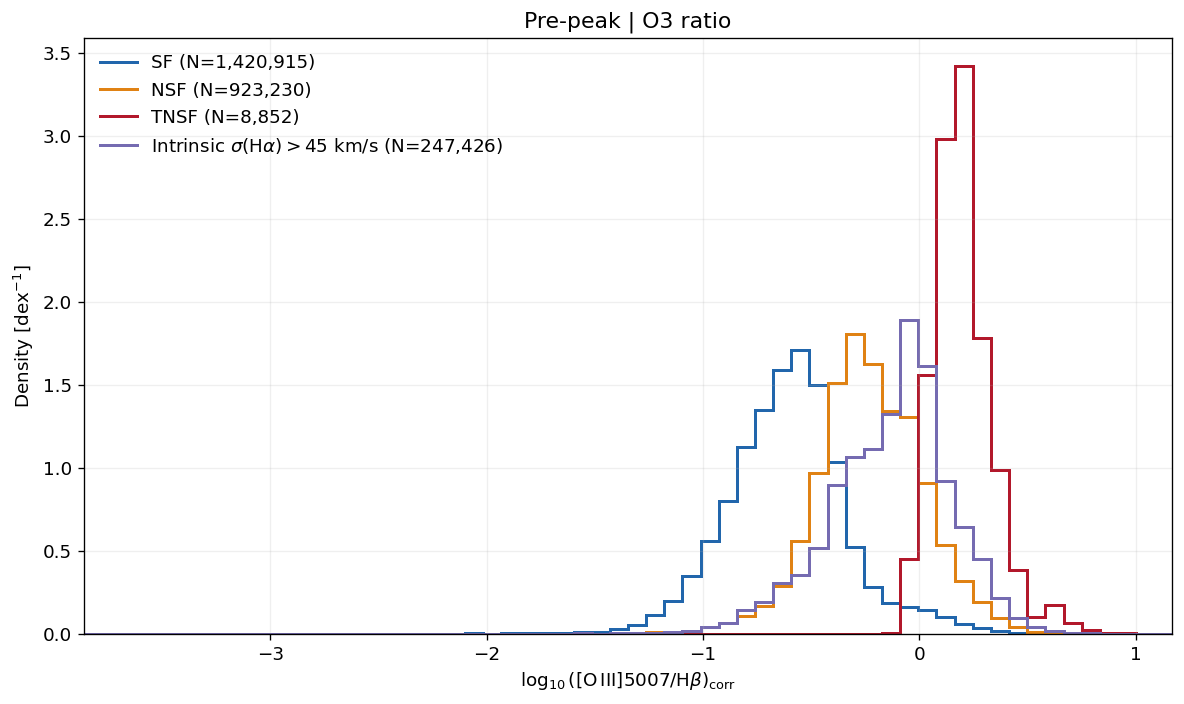

In [6]:
plot_stage_pdf("pre-peak", "O3")


Pre-peak | N2
SF: N=1,420,915; log10 range=[-1.23906, -0.206147]; median=-0.454618; linear range=[0.0576682, 0.62209]; median=0.351061; integral=1
NSF: N=929,104; log10 range=[-1.10173, 0.316024]; median=-0.237373; linear range=[0.0791173, 2.07025]; median=0.578931; integral=1
TNSF: N=8,852; log10 range=[-0.353802, 0.316024]; median=0.0758755; linear range=[0.44279, 2.07025]; median=1.1909; integral=1
SIGMA_GT45: N=247,677; log10 range=[-1.10173, 0.316024]; median=-0.173843; linear range=[0.0791173, 2.07025]; median=0.670127; integral=1


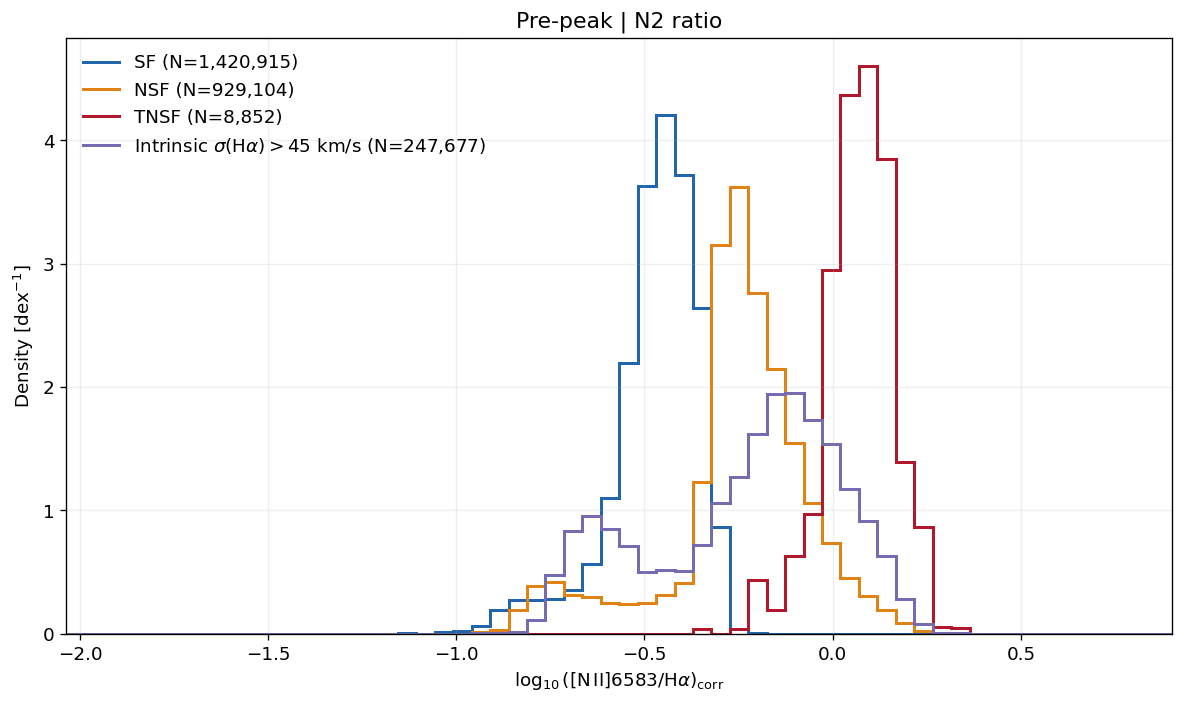

In [7]:
plot_stage_pdf("pre-peak", "N2")


Pre-peak | S2
SF: N=1,420,915; log10 range=[-1.22966, -0.113984]; median=-0.516374; linear range=[0.0589311, 0.769158]; median=0.304527; integral=1
NSF: N=929,091; log10 range=[-1.38133, 0.398809]; median=-0.285683; linear range=[0.0415596, 2.50501]; median=0.517985; integral=1
TNSF: N=8,852; log10 range=[-0.649789, 0.0759481]; median=-0.105164; linear range=[0.223981, 1.1911]; median=0.78494; integral=1
SIGMA_GT45: N=247,664; log10 range=[-1.38133, 0.296161]; median=-0.289563; linear range=[0.0415596, 1.9777]; median=0.513378; integral=1


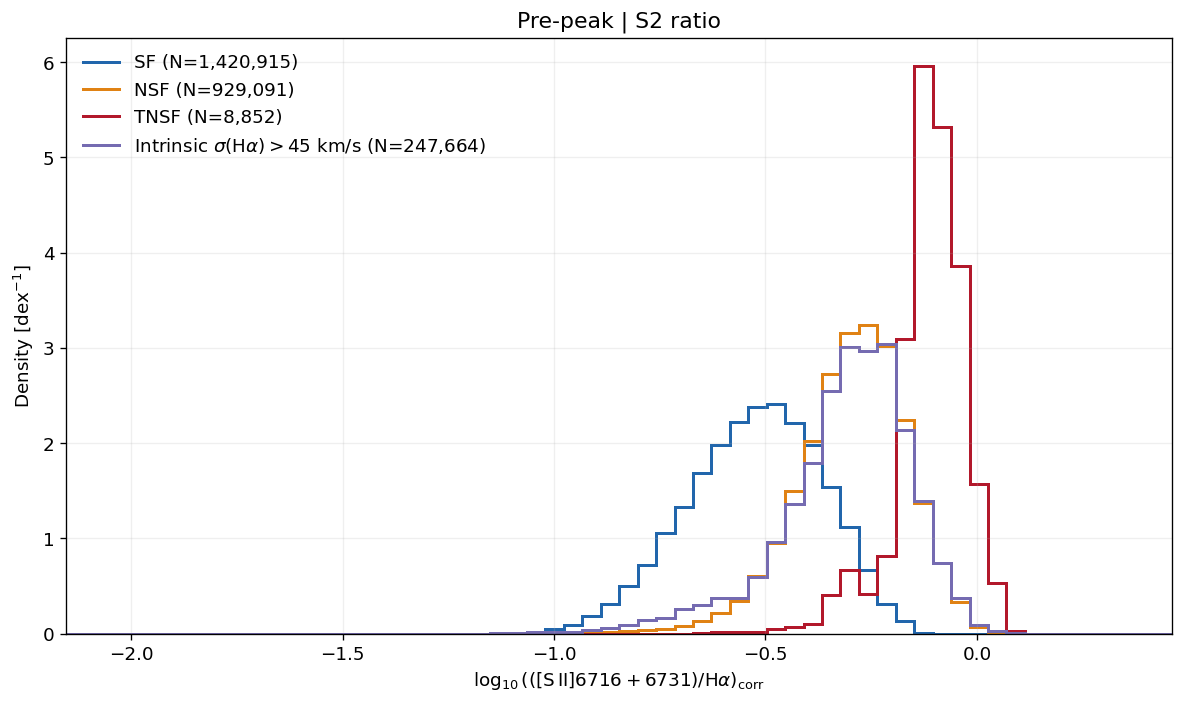

In [8]:
plot_stage_pdf("pre-peak", "S2")

## Close-to-peak distributions


Close-to-peak | O3
SF: N=720,842; log10 range=[-2.33887, 0.282423]; median=-0.549554; linear range=[0.00458282, 1.91612]; median=0.282128; integral=1
NSF: N=486,897; log10 range=[-2.93036, 0.846801]; median=-0.193511; linear range=[0.00117393, 7.0275]; median=0.640455; integral=1
TNSF: N=6,217; log10 range=[-0.180506, 0.834861]; median=0.235461; linear range=[0.659924, 6.83692]; median=1.71973; integral=1
SIGMA_GT45: N=124,776; log10 range=[-1.98218, 0.846801]; median=-0.0680653; linear range=[0.0104189, 7.0275]; median=0.854938; integral=1


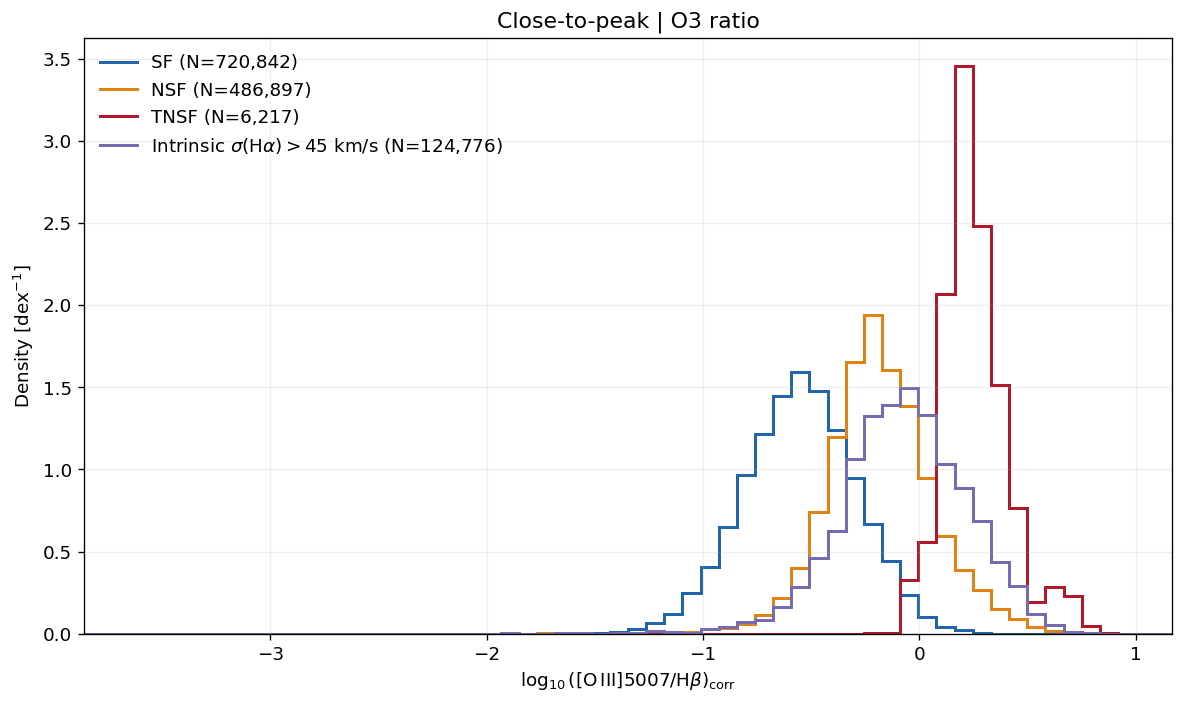

In [9]:
plot_stage_pdf("close-to-peak", "O3")


Close-to-peak | N2
SF: N=720,842; log10 range=[-0.837894, -0.233873]; median=-0.470324; linear range=[0.145247, 0.583616]; median=0.338592; integral=1
NSF: N=488,603; log10 range=[-1.15332, 0.455736]; median=-0.248409; linear range=[0.070256, 2.85586]; median=0.564406; integral=1
TNSF: N=6,217; log10 range=[-0.523908, 0.455736]; median=0.0886254; linear range=[0.29929, 2.85586]; median=1.22638; integral=1
SIGMA_GT45: N=125,566; log10 range=[-1.15332, 0.455736]; median=-0.166481; linear range=[0.070256, 2.85586]; median=0.681583; integral=1


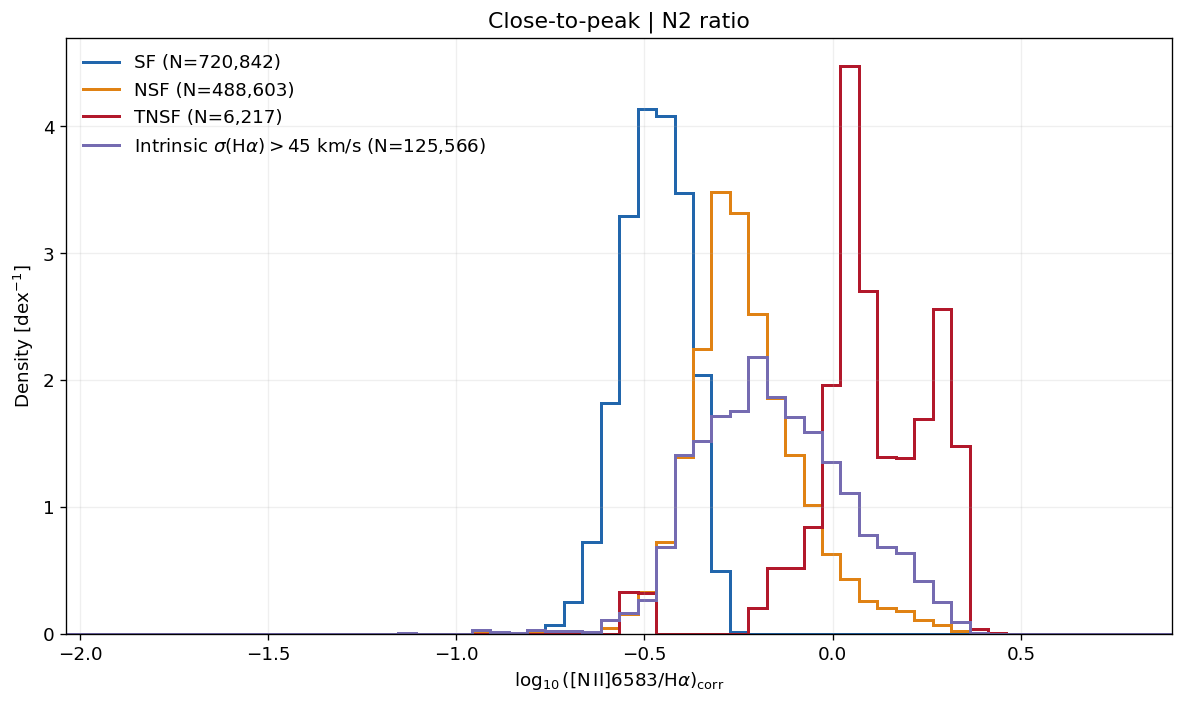

In [10]:
plot_stage_pdf("close-to-peak", "N2")


Close-to-peak | S2
SF: N=720,842; log10 range=[-1.14064, -0.117507]; median=-0.46795; linear range=[0.0723375, 0.762945]; median=0.340447; integral=1
NSF: N=488,345; log10 range=[-2.15357, 0.462026]; median=-0.226357; linear range=[0.00702148, 2.89752]; median=0.593803; integral=1
TNSF: N=6,217; log10 range=[-0.377018, 0.217263]; median=-0.0570892; linear range=[0.419741, 1.64916]; median=0.876821; integral=1
SIGMA_GT45: N=125,308; log10 range=[-2.15357, 0.462026]; median=-0.155018; linear range=[0.00702148, 2.89752]; median=0.699812; integral=1


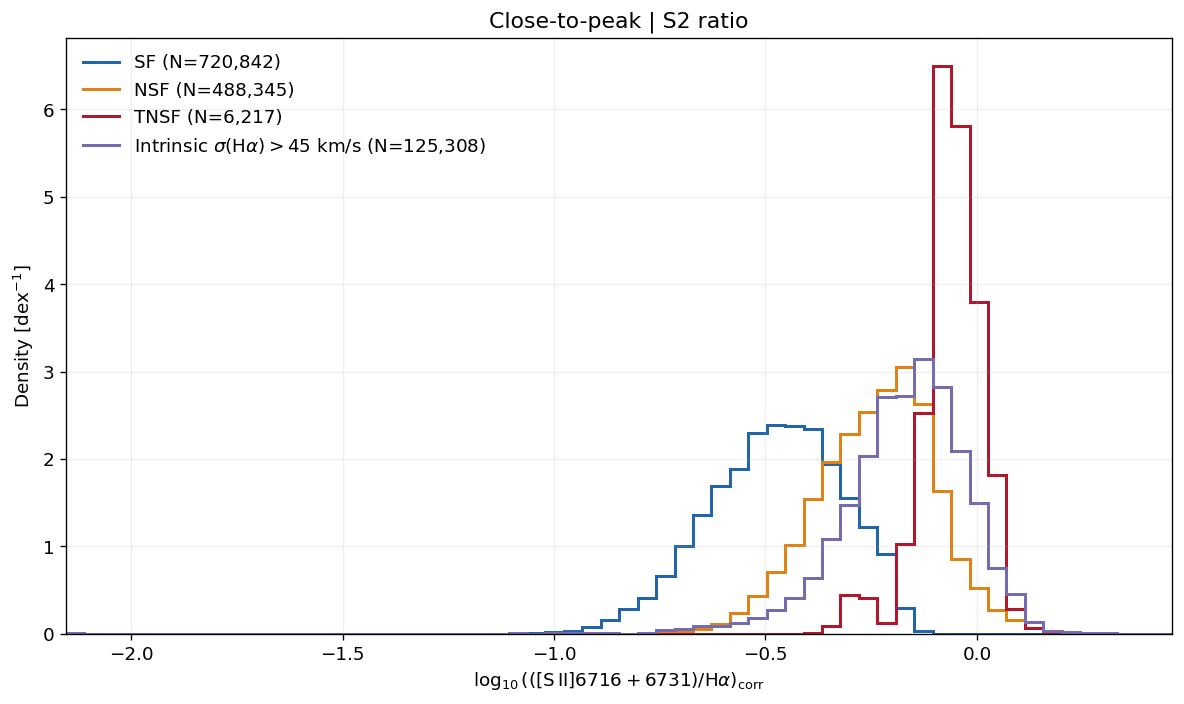

In [11]:
plot_stage_pdf("close-to-peak", "S2")

## Post-peak distributions


Post-peak | O3
SF: N=222,427; log10 range=[-2.60065, 0.105936]; median=-0.683935; linear range=[0.00250812, 1.27625]; median=0.207045; integral=1
NSF: N=811,269; log10 range=[-3.46679, 1.16971]; median=0.049779; linear range=[0.000341355, 14.7811]; median=1.12145; integral=1
TNSF: N=94,780; log10 range=[-0.252255, 1.16971]; median=0.25353; linear range=[0.559429, 14.7811]; median=1.79279; integral=1
SIGMA_GT45: N=452,706; log10 range=[-3.46679, 1.08988]; median=0.143768; linear range=[0.000341355, 12.2992]; median=1.39241; integral=1


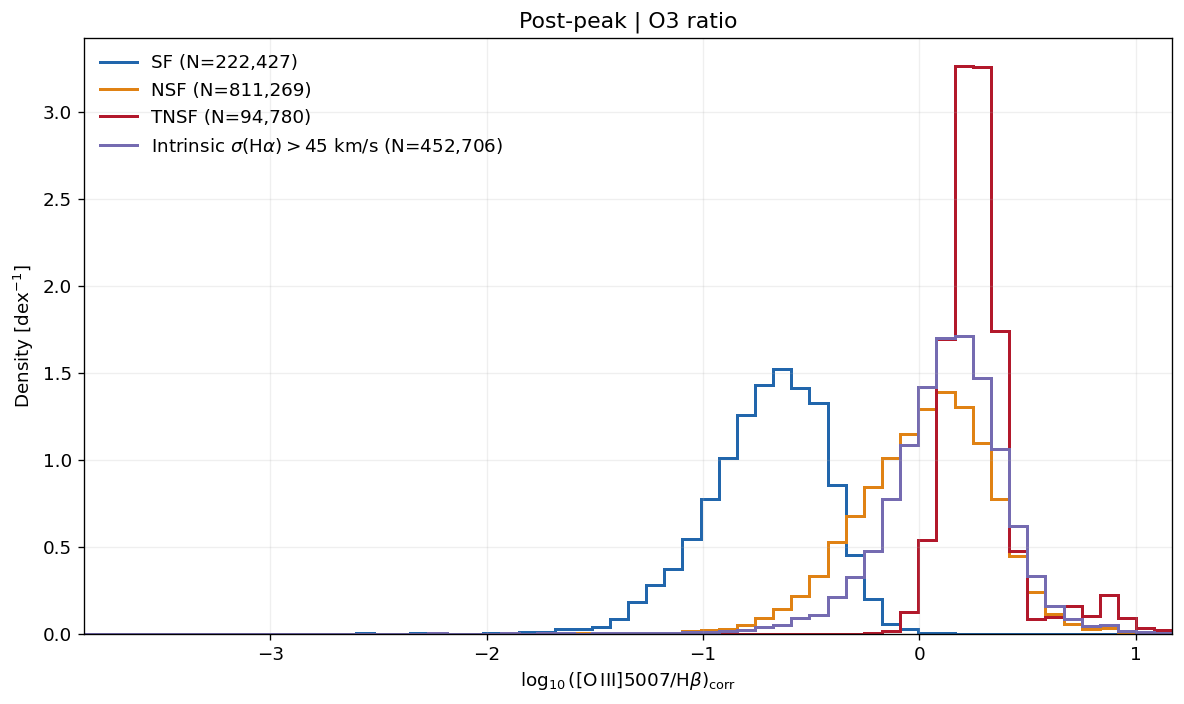

In [12]:
plot_stage_pdf("post-peak", "O3")


Post-peak | N2
SF: N=222,427; log10 range=[-1.03267, -0.231202]; median=-0.47199; linear range=[0.0927525, 0.587216]; median=0.337295; integral=1
NSF: N=815,489; log10 range=[-2.03665, 0.902431]; median=-0.0505449; linear range=[0.00919082, 7.98787]; median=0.890133; integral=1
TNSF: N=94,780; log10 range=[-0.302621, 0.571421]; median=0.0881248; linear range=[0.498172, 3.72753]; median=1.22497; integral=1
SIGMA_GT45: N=454,308; log10 range=[-2.03665, 0.902431]; median=0.00690691; linear range=[0.00919082, 7.98787]; median=1.01603; integral=1


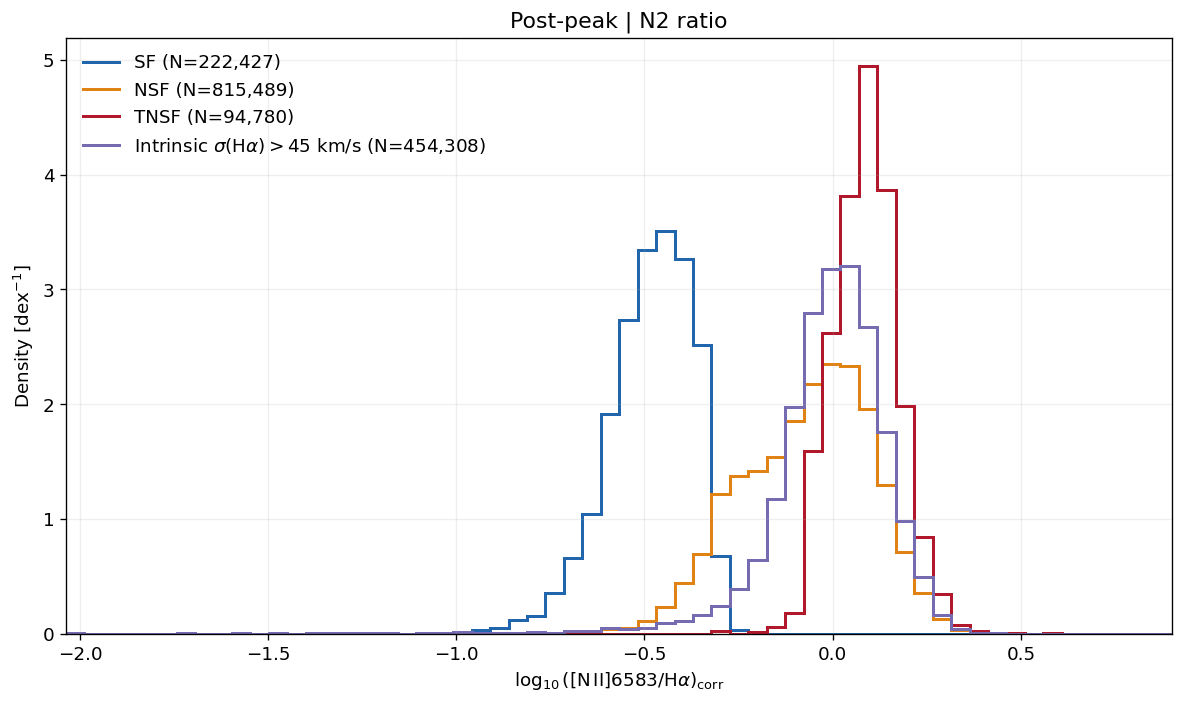

In [13]:
plot_stage_pdf("post-peak", "N2")


Post-peak | S2
SF: N=222,427; log10 range=[-1.19513, -0.223488]; median=-0.618226; linear range=[0.0638075, 0.59774]; median=0.240865; integral=1
NSF: N=810,743; log10 range=[-1.8706, 0.370517]; median=-0.184716; linear range=[0.013471, 2.34702]; median=0.653558; integral=1
TNSF: N=94,780; log10 range=[-0.492621, 0.370517]; median=-0.0225378; linear range=[0.321647, 2.34702]; median=0.949428; integral=1
SIGMA_GT45: N=449,814; log10 range=[-1.55941, 0.361954]; median=-0.130871; linear range=[0.0275795, 2.3012]; median=0.739824; integral=1


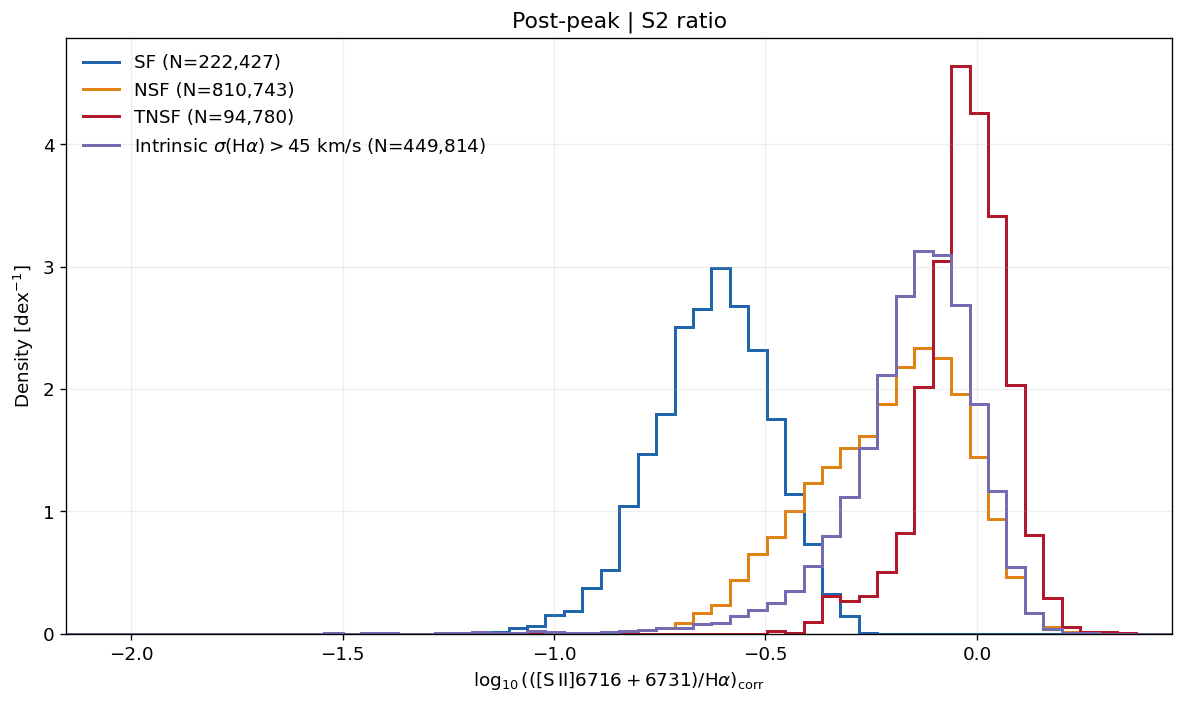

In [14]:
plot_stage_pdf("post-peak", "S2")


Pre-peak | N2 | combined histogram
SF: N=1,420,915; log10 range=[-1.23906, -0.206147]; median=-0.454618; linear range=[0.0576682, 0.62209]; median=0.351061
NSF: N=929,104; log10 range=[-1.10173, 0.316024]; median=-0.237373; linear range=[0.0791173, 2.07025]; median=0.578931
TNSF: N=8,852; log10 range=[-0.353802, 0.316024]; median=0.0758755; linear range=[0.44279, 2.07025]; median=1.1909
SIGMA_GT45: N=247,677; log10 range=[-1.10173, 0.316024]; median=-0.173843; linear range=[0.0791173, 2.07025]; median=0.670127

Pre-peak | S2 | combined histogram
SF: N=1,420,915; log10 range=[-1.22966, -0.113984]; median=-0.516374; linear range=[0.0589311, 0.769158]; median=0.304527
NSF: N=929,091; log10 range=[-1.38133, 0.398809]; median=-0.285683; linear range=[0.0415596, 2.50501]; median=0.517985
TNSF: N=8,852; log10 range=[-0.649789, 0.0759481]; median=-0.105164; linear range=[0.223981, 1.1911]; median=0.78494
SIGMA_GT45: N=247,664; log10 range=[-1.38133, 0.296161]; median=-0.289563; linear range=[

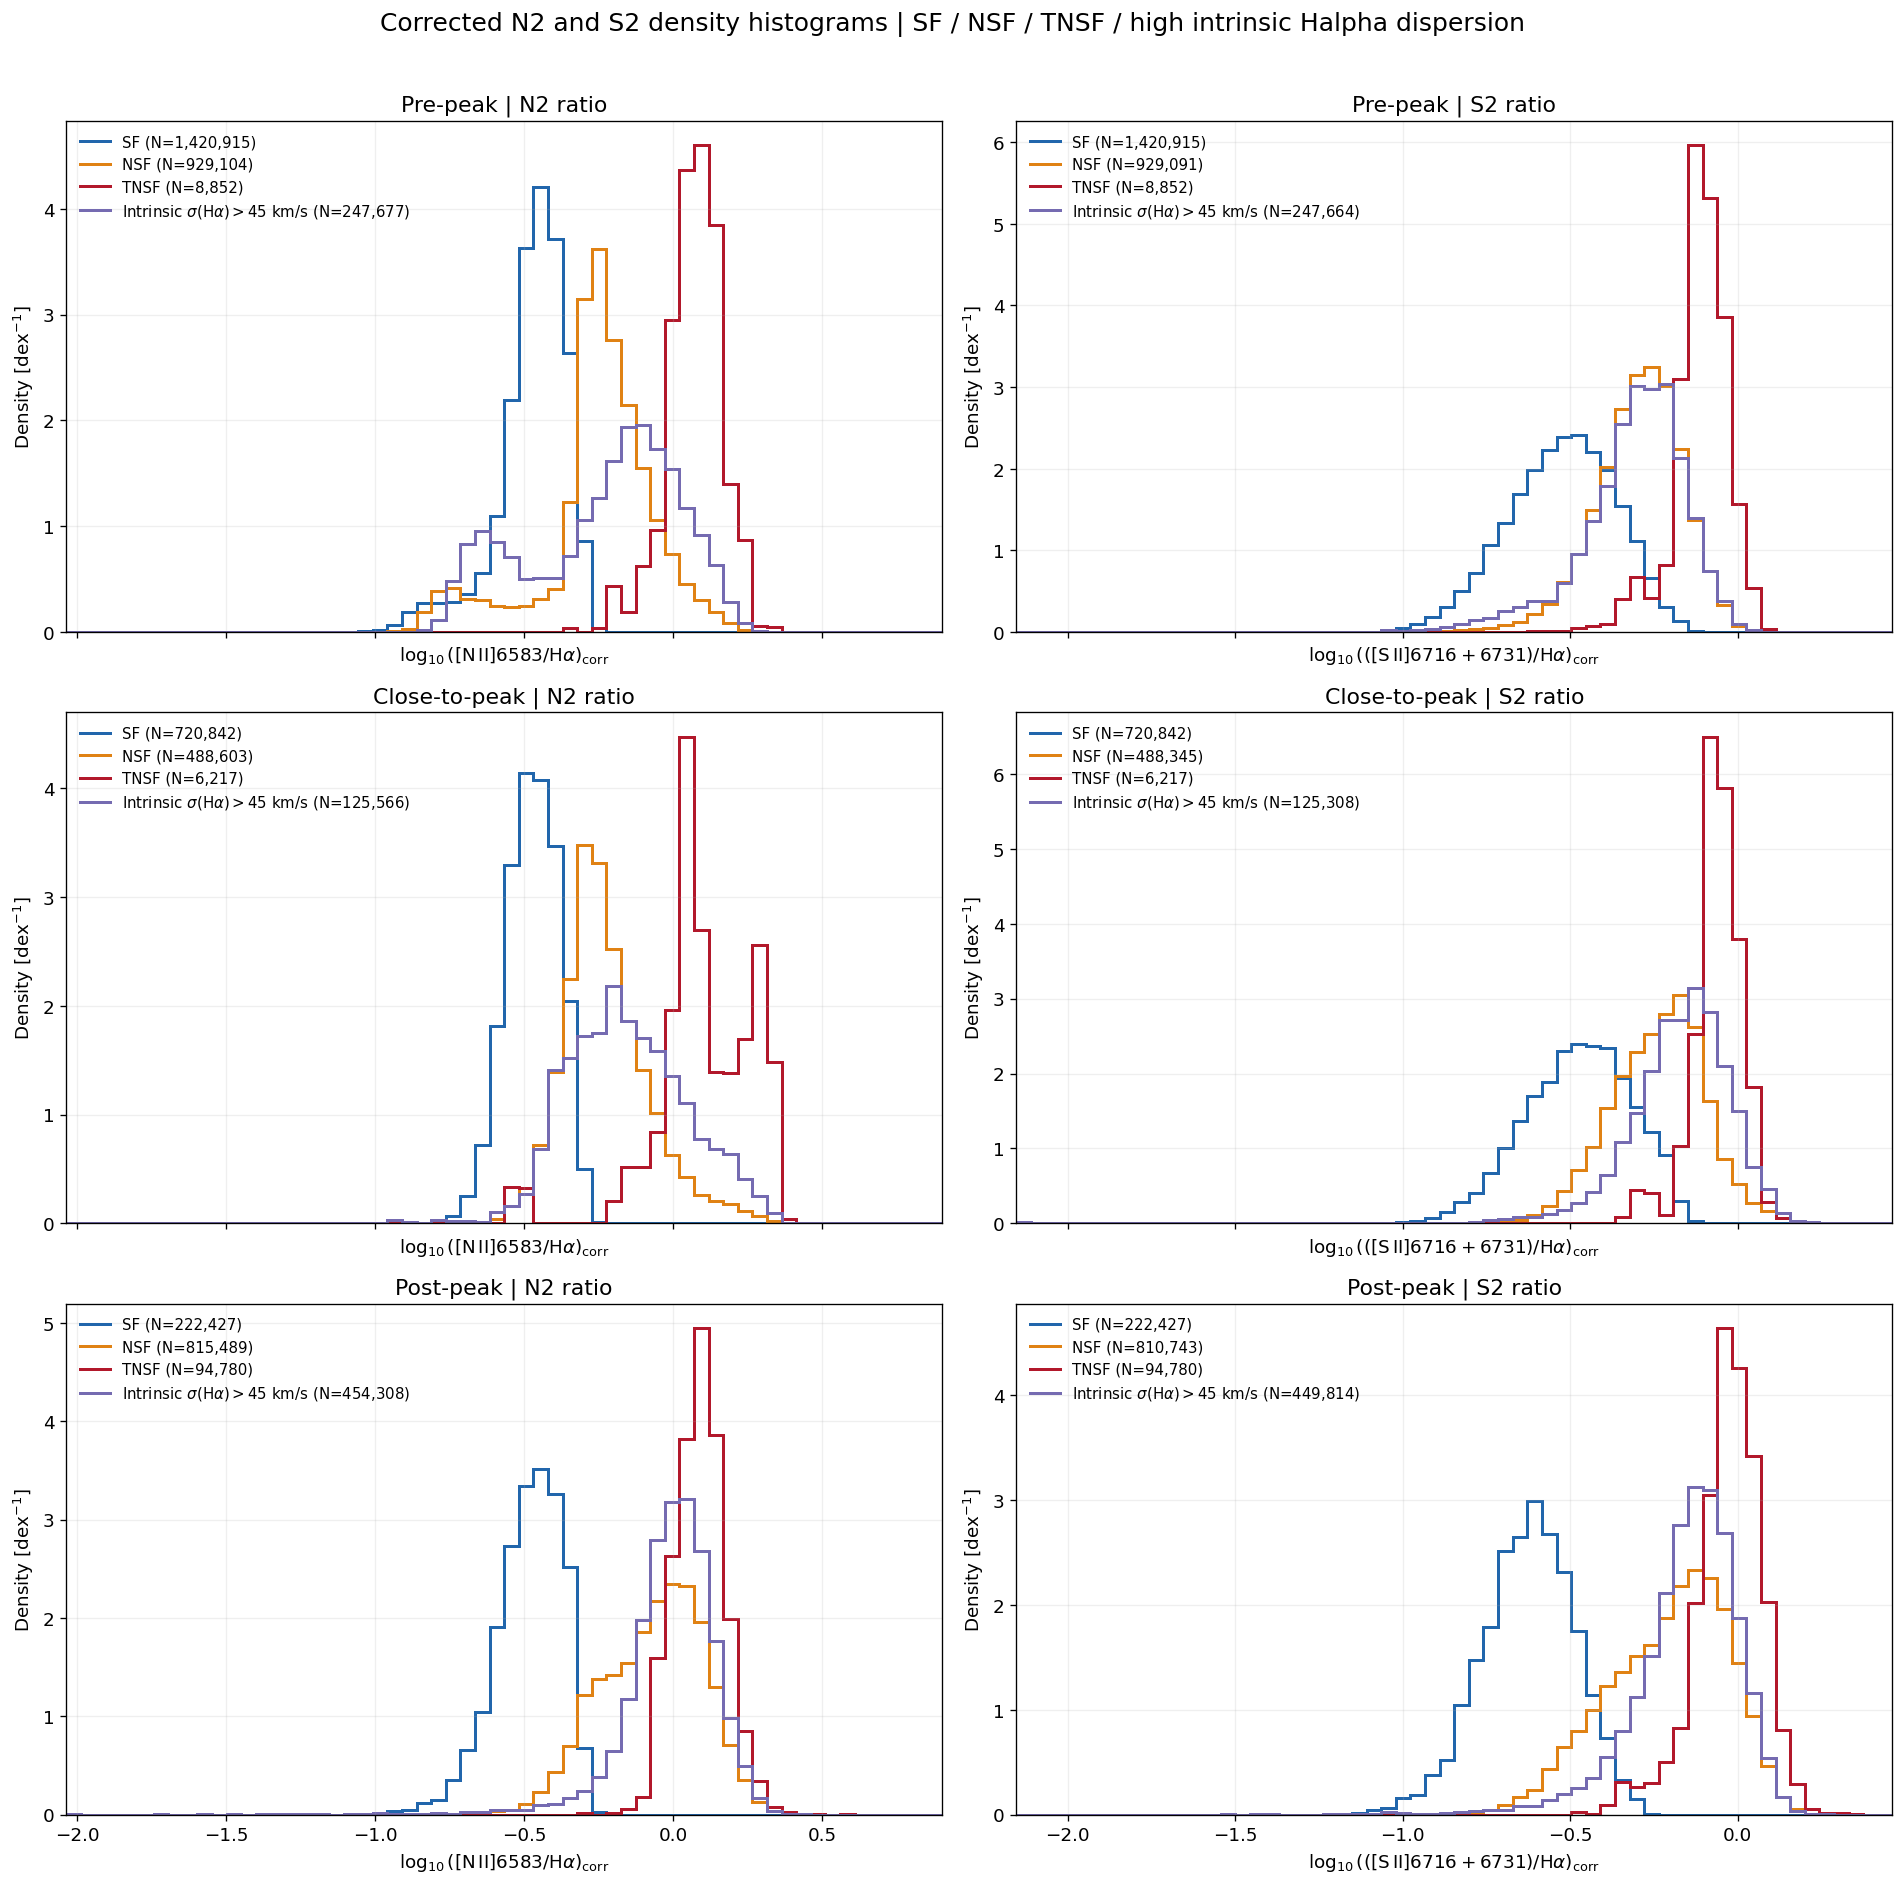

In [15]:
# Combined N2/S2 density histograms: stages in rows, ratios in columns.
fig, axes = plt.subplots(3, 2, figsize=(16, 16), sharex='col')
for i, stage in enumerate(STAGE_ORDER):
    for j, observable in enumerate(('N2', 'S2')):
        ax = axes[i, j]
        edges = COMMON_EDGES[observable]
        print(f'\n{STAGE_LABELS[stage]} | {observable} | combined histogram')
        for category in CATEGORY_ORDER:
            values = POOLED[stage, observable, category]
            if values.size:
                counts = np.histogram(values, bins=edges)[0]
                density = counts / (values.size * np.diff(edges))
                linear = 10.0**values
                print(f'{category}: N={values.size:,}; '
                      f'log10 range=[{values.min():.6g}, {values.max():.6g}]; '
                      f'median={np.median(values):.6g}; '
                      f'linear range=[{linear.min():.6g}, {linear.max():.6g}]; '
                      f'median={np.median(linear):.6g}')
                ax.stairs(density, edges, color=CATEGORY_COLORS[category], linewidth=1.8,
                          label=f'{CATEGORY_LABELS[category]} (N={values.size:,})')
            else:
                print(f'{category}: empty; density unavailable')
                ax.plot([], [], color=CATEGORY_COLORS[category],
                        label=CATEGORY_LABELS[category] + ' (empty)')
        ax.set(xlim=(edges[0], edges[-1]), ylim=(0, None),
               xlabel=OBSERVABLE_LABELS[observable], ylabel=r'Density [dex$^{-1}$]',
               title=STAGE_LABELS[stage] + ' | ' + OBSERVABLE_TITLES[observable])
        ax.legend(frameon=False, fontsize=9)
        ax.grid(alpha=0.2)
fig.suptitle('Corrected N2 and S2 density histograms | SF / NSF / TNSF / high intrinsic Halpha dispersion',
             fontsize=15)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()
plt.close(fig)


## Actual BPT positions: intrinsic Halpha dispersion >45 km/s
Three rows in stage order; NII left and SII right. Purple points show every finite paired spaxel in the selected sample. Limits cover the complete plotted data and the usual reference window; both axes share limits across stages.

pre-peak | NII: selected=247,677; paired=247,426; unavailable=251; all paired points plotted
pre-peak | SII: selected=247,677; paired=247,413; unavailable=264; all paired points plotted
close-to-peak | NII: selected=125,828; paired=124,776; unavailable=1,052; all paired points plotted
close-to-peak | SII: selected=125,828; paired=124,510; unavailable=1,318; all paired points plotted
post-peak | NII: selected=454,706; paired=452,410; unavailable=2,296; all paired points plotted
post-peak | SII: selected=454,706; paired=448,004; unavailable=6,702; all paired points plotted


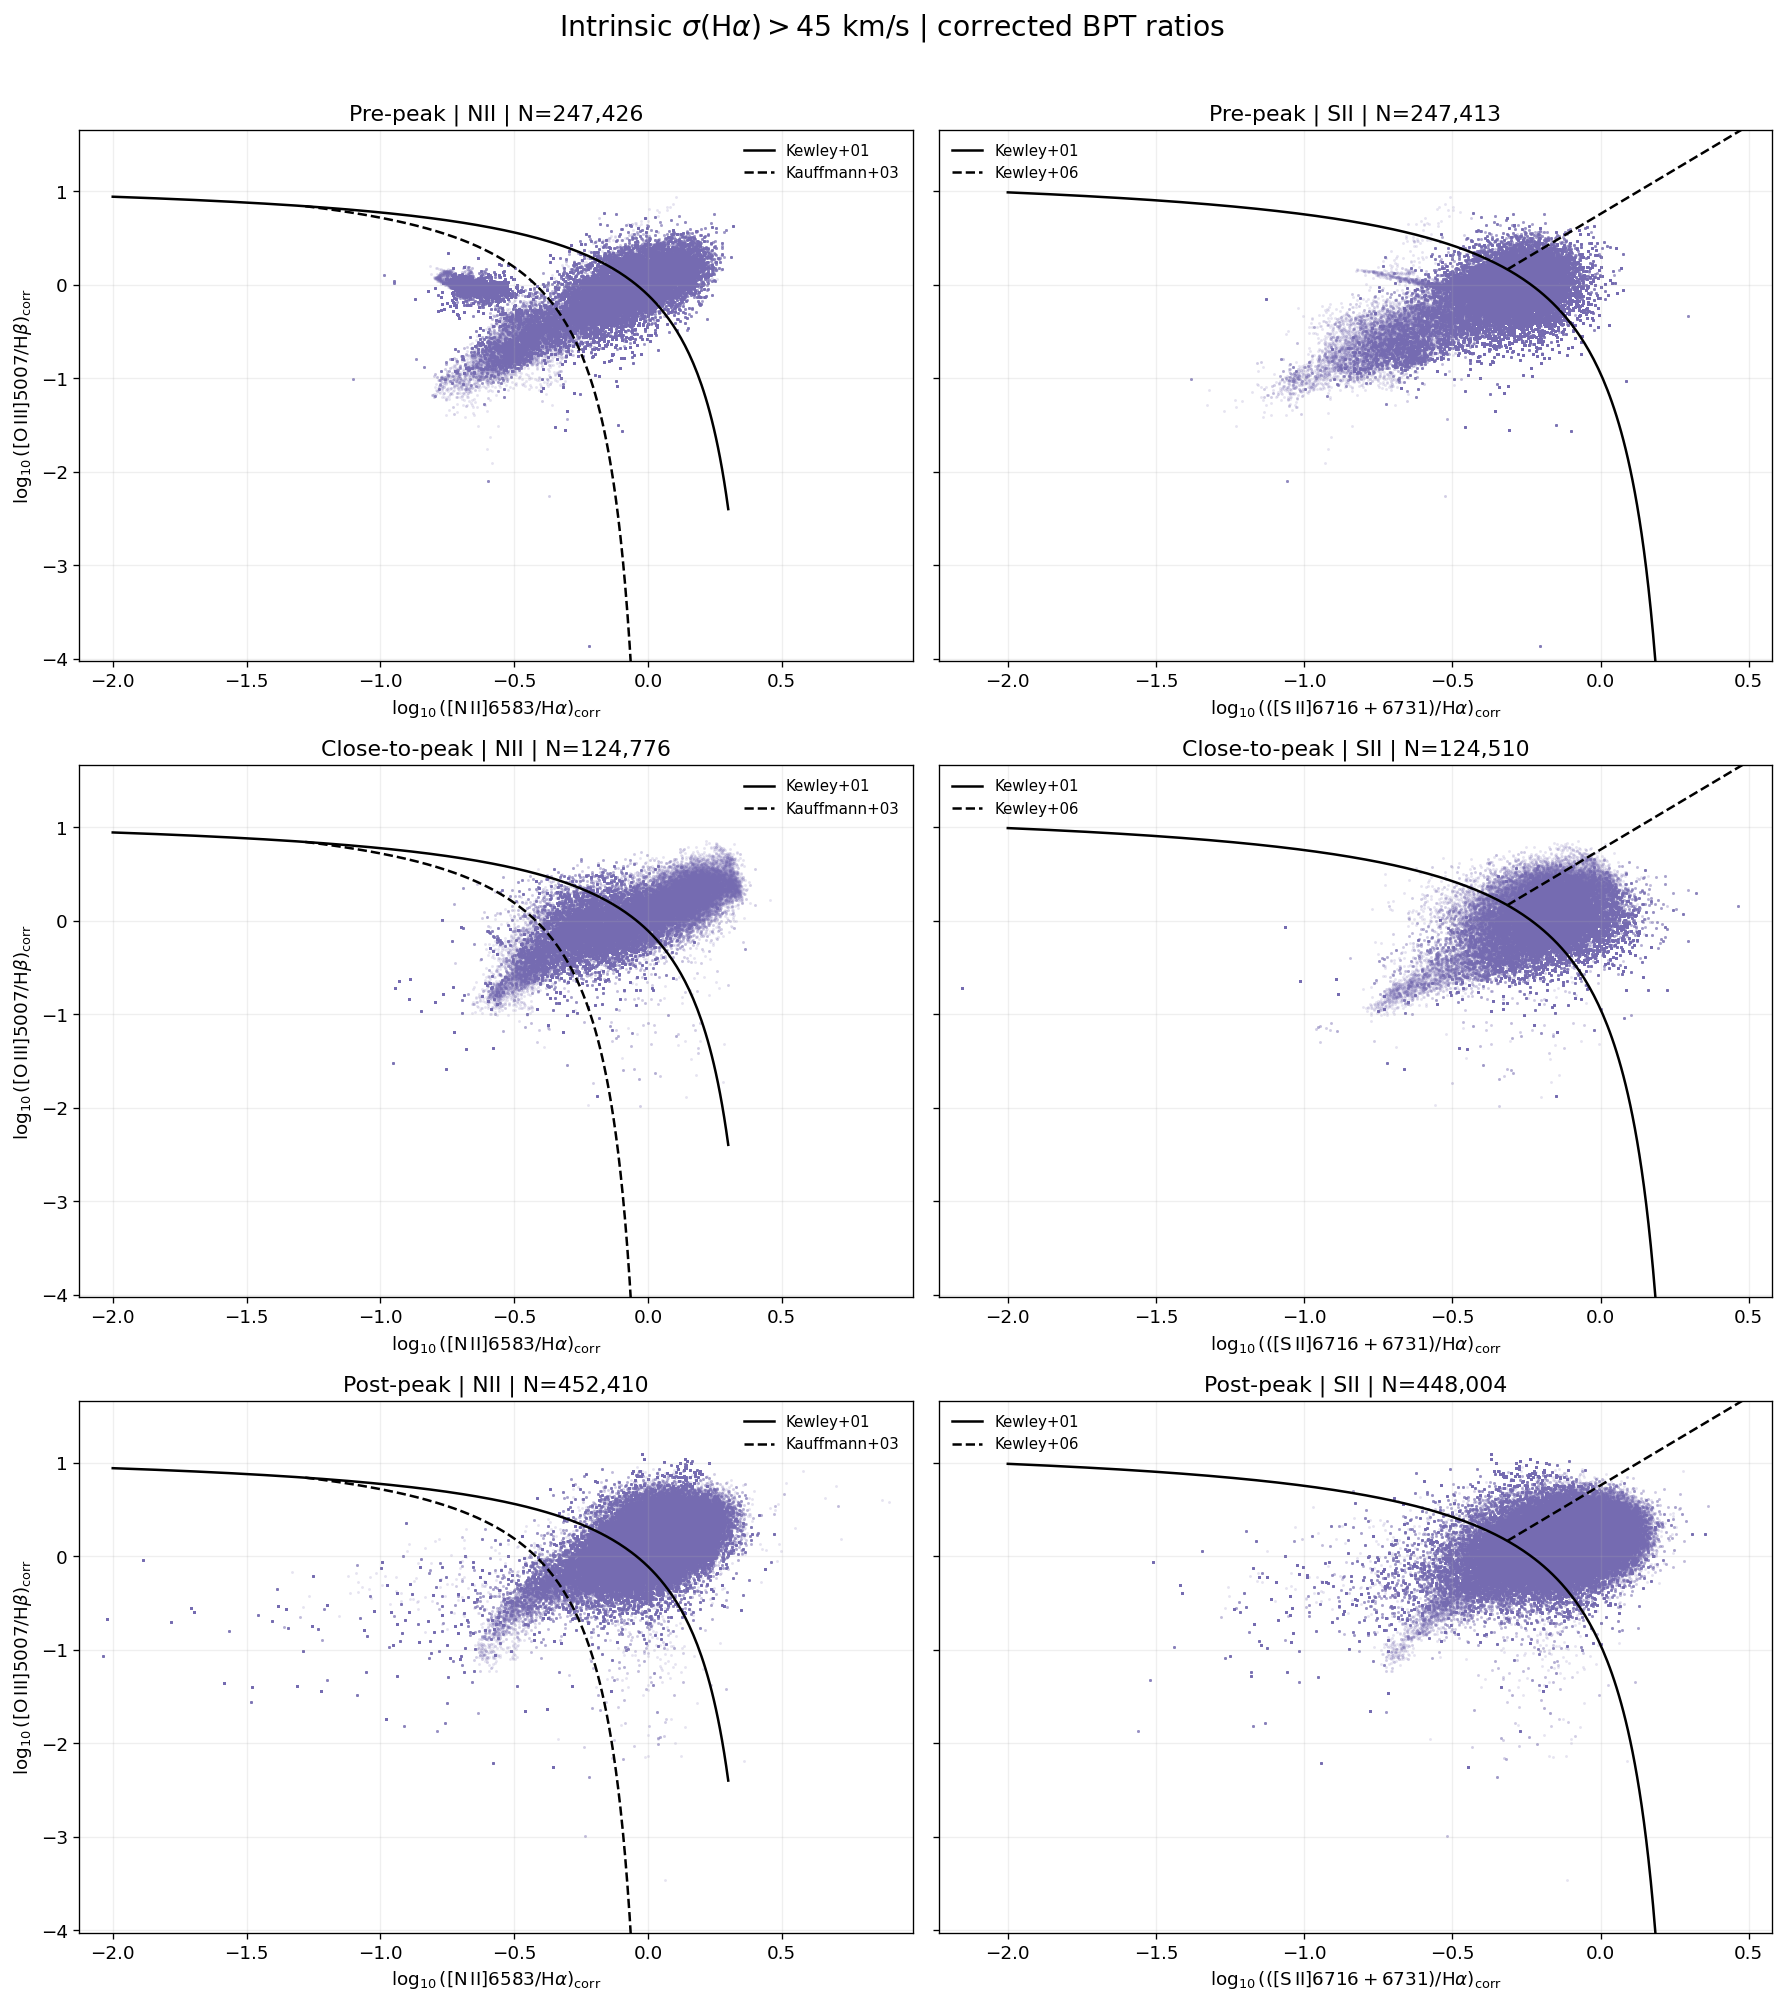

In [16]:
DIAGRAMS = ('NII', 'SII')
STAGE_PAIRS = {}
for stage in STAGE_ORDER:
    for diagram in DIAGRAMS:
        arrays = [r[diagram] for r in BPT_BY_GALAXY if r['stage'] == stage]
        STAGE_PAIRS[stage, diagram] = np.concatenate(arrays) if arrays else np.empty((0, 2))
def full_limits(arrays, axis, default):
    values = [p[:, axis] for p in arrays if len(p)]
    lo = min([default[0]] + [v.min() for v in values])
    hi = max([default[1]] + [v.max() for v in values])
    pad = 0.03 * (hi-lo)
    return lo-pad, hi+pad
BPT_XLIM = {d: full_limits([STAGE_PAIRS[s, d] for s in STAGE_ORDER], 0, (-2.0, 0.5)) for d in DIAGRAMS}
BPT_YLIM = full_limits(list(STAGE_PAIRS.values()), 1, (-1.5, 1.5))
BPT_PLOT_CHECKS = []
fig, axes = plt.subplots(3, 2, figsize=(15, 17), sharey=True)
for i, stage in enumerate(STAGE_ORDER):
    for j, diagram in enumerate(DIAGRAMS):
        ax = axes[i, j]
        pairs = STAGE_PAIRS[stage, diagram]
        points = ax.scatter(pairs[:, 0], pairs[:, 1], s=3, alpha=0.18,
                            color=CATEGORY_COLORS['SIGMA_GT45'], linewidths=0, rasterized=True)
        if diagram == 'NII':
            x = np.linspace(-2, 0.3, 300)
            ax.plot(x, 0.61/(x-0.47)+1.19, color='black', label='Kewley+01')
            x = np.linspace((286-np.sqrt(2871561))/1100, 0, 300)
            ax.plot(x, 0.61/(x-0.05)+1.30, color='black', linestyle='--', label='Kauffmann+03')
            xlabel = OBSERVABLE_LABELS['N2']
        else:
            x = np.linspace(-2, 0.3, 300)
            ax.plot(x, 0.72/(x-0.32)+1.30, color='black', label='Kewley+01')
            x = np.linspace((159-np.sqrt(105081))/525, 0.5, 300)
            ax.plot(x, 1.89*x+0.76, color='black', linestyle='--', label='Kewley+06')
            xlabel = OBSERVABLE_LABELS['S2']
        ax.set(xlim=BPT_XLIM[diagram], ylim=BPT_YLIM, xlabel=xlabel,
               title=f'{STAGE_LABELS[stage]} | {diagram} | N={len(pairs):,}')
        if j == 0:
            ax.set_ylabel(OBSERVABLE_LABELS['O3'])
        ax.legend(frameon=False, fontsize=9)
        ax.grid(alpha=0.2)
        if not len(pairs):
            ax.text(0.5, 0.5, 'No finite paired data', transform=ax.transAxes, ha='center')
        subset = BPT_COUNTS.loc[BPT_COUNTS.stage.eq(stage) & BPT_COUNTS.diagram.eq(diagram)]
        print(f'{stage} | {diagram}: selected={subset.N_selected.sum():,}; paired={len(pairs):,}; '
              f'unavailable={subset.N_unavailable.sum():,}; all paired points plotted')
        assert len(pairs) == subset.N_paired.sum()
        assert np.isfinite(pairs).all()
        assert points.get_offsets().shape[0] == len(pairs)
        BPT_PLOT_CHECKS.append(True)
fig.suptitle(r'Intrinsic $\sigma(\mathrm{H}\alpha)>45$ km/s | corrected BPT ratios', fontsize=17)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()
plt.close(fig)


## Numerical validation summary

In [17]:
PDF_SUMMARY = pd.DataFrame(PDF_SUMMARY_ROWS)
assert len(PDF_SUMMARY) == len(STAGE_ORDER)*len(OBSERVABLE_ORDER)*len(CATEGORY_ORDER)
assert not PDF_SUMMARY.duplicated(['stage', 'observable', 'category']).any()
assert np.allclose(PDF_SUMMARY.loc[PDF_SUMMARY.N_spaxel.gt(0), 'PDF_integral'], 1)
assert MEASUREMENT_COUNTS.N_selected.eq(MEASUREMENT_COUNTS.N_finite+MEASUREMENT_COUNTS.N_unavailable).all()
assert BPT_COUNTS.N_selected.eq(BPT_COUNTS.N_paired+BPT_COUNTS.N_unavailable).all()
assert (OVERLAP_COUNTS.N_high_sigma <= OVERLAP_COUNTS.N_NSF).all()
assert len(BPT_PLOT_CHECKS) == 6 and all(BPT_PLOT_CHECKS)
display(PDF_SUMMARY)
print('RATIO_INTRINSIC_SIGMA_VALIDATION_OK: 9 histogram figures, 36 distributions, 6 BPT panels')


,stage,observable,category,N_spaxel,PDF_integral
0,pre-peak,O3,SF,1420915,1.0
1,pre-peak,O3,NSF,923230,1.0
2,pre-peak,O3,TNSF,8852,1.0
3,pre-peak,O3,SIGMA_GT45,247426,1.0
4,pre-peak,N2,SF,1420915,1.0
5,pre-peak,N2,NSF,929104,1.0
6,pre-peak,N2,TNSF,8852,1.0
7,pre-peak,N2,SIGMA_GT45,247677,1.0
8,pre-peak,S2,SF,1420915,1.0
9,pre-peak,S2,NSF,929091,1.0


RATIO_INTRINSIC_SIGMA_VALIDATION_OK: 9 histogram figures, 36 distributions, 6 BPT panels
